In [1]:
import numpy as np
import influ
from influ.F2 import F2
from influ.DMD import DMD
from influ.utils import *

In [2]:
sigma=0.9
T=10
low=-1
ND=5
Csn_factor=1
Ntraj=10000
Npop=[2000]*ND
counts_per_demeweek=300
Csn=[Csn_factor]*ND

A=np.diag(np.ones(ND))
A+=np.random.uniform(size=(ND,ND))/ND
A/=np.expand_dims(A.sum(axis=1),1) # normalize

A,counts,B=WF_sim(Npop,counts_per_demeweek, Csn, ND, T, A=A,Ntraj=Ntraj, freqini=[],sigma=sigma,low=low)
totcounts= np.ones(counts.shape)*counts_per_demeweek

In [20]:
# initialize classes
F2_inference=F2(counts,totcounts)
DMD_inference=DMD(counts,totcounts)

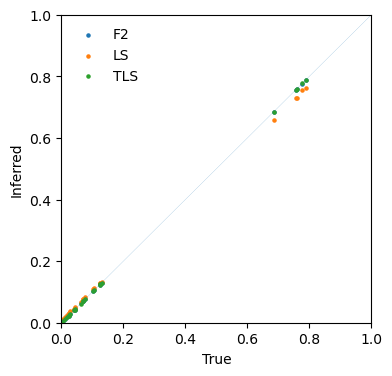

In [23]:
A_F2=F2_inference.infer()
A_LS=DMD_inference.infer(); # least square option
A_TLS=DMD_inference.infer(we=0.9); # Total least square option: for the moment the parameter we is hyperparameter, can we automatically set it up?

plt.figure(figsize=(4,4))
plt.scatter(A,A_F2,s=5,label='F2')
plt.scatter(A,A_LS,s=5,label='LS')
plt.scatter(A,A_TLS,s=5,label='TLS')
plt.xlim([0,1])
plt.ylim([0,1])
plt.plot([0,1],linewidth=0.1)
plt.xlabel("True")
plt.ylabel("Inferred")
plt.legend(frameon=False)
plt.show()